# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

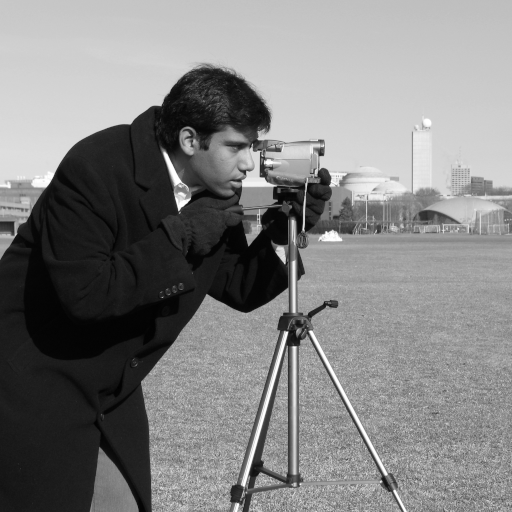

In [4]:
# ── Load image ────────────────────────────────────
from skimage import data
image = Image.fromarray(data.camera())
image

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [5]:
# Get the size of the image
width, height = image.size
print(f"Original size: {width} x {height}")

# scaling factors
scale_x = 2
scale_y = 2

Original size: 512 x 512


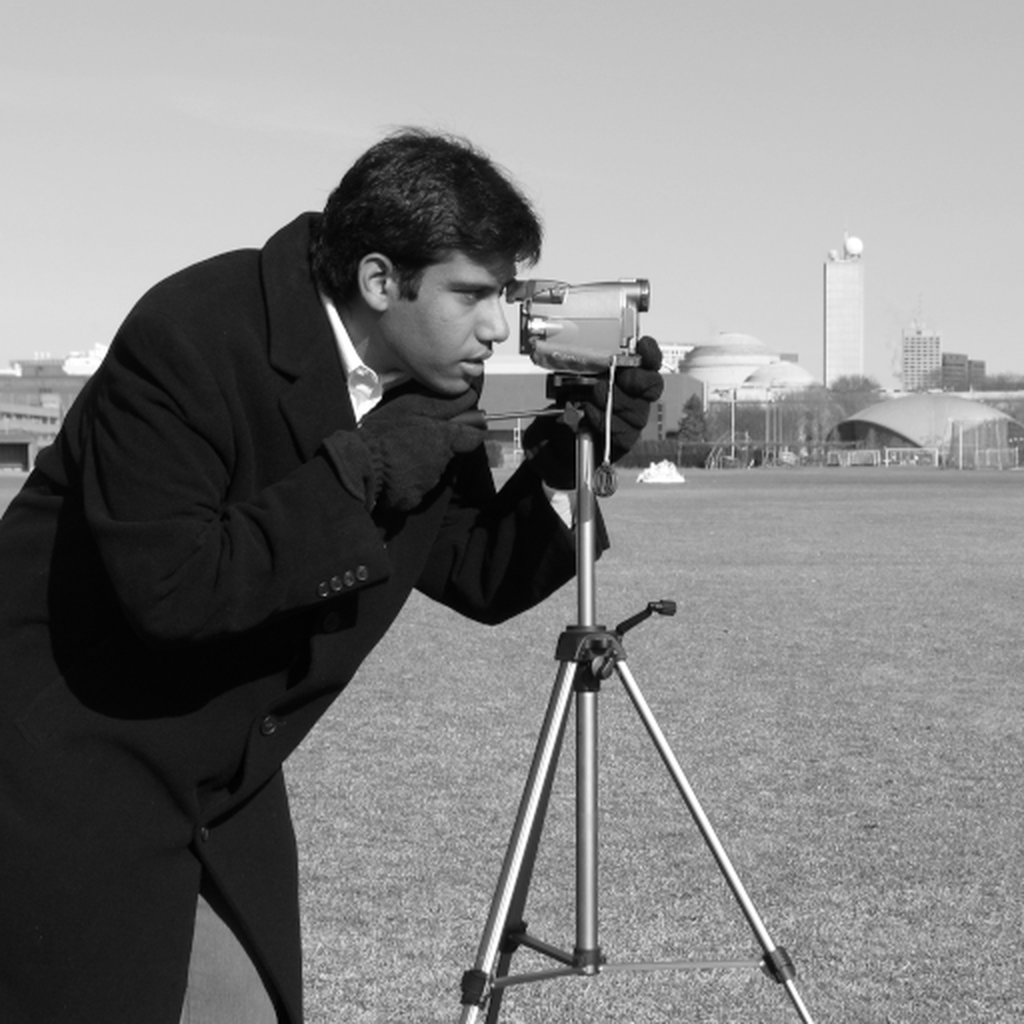

In [6]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
new_size = (width * scale_x, height * scale_y)
scaled_image = image.resize(new_size, Image.Resampling.LANCZOS)

scaled_image

In [7]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_image.save("task1_1_scaled.jpg")
print(f"Original size: {image.size}")
print(f"Scaled size: {scaled_image.size}")

Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [8]:
# non-uniform scaling factors
cx = 2  # stretch horizontally
cy = 1  # keep the vertical size unchanged

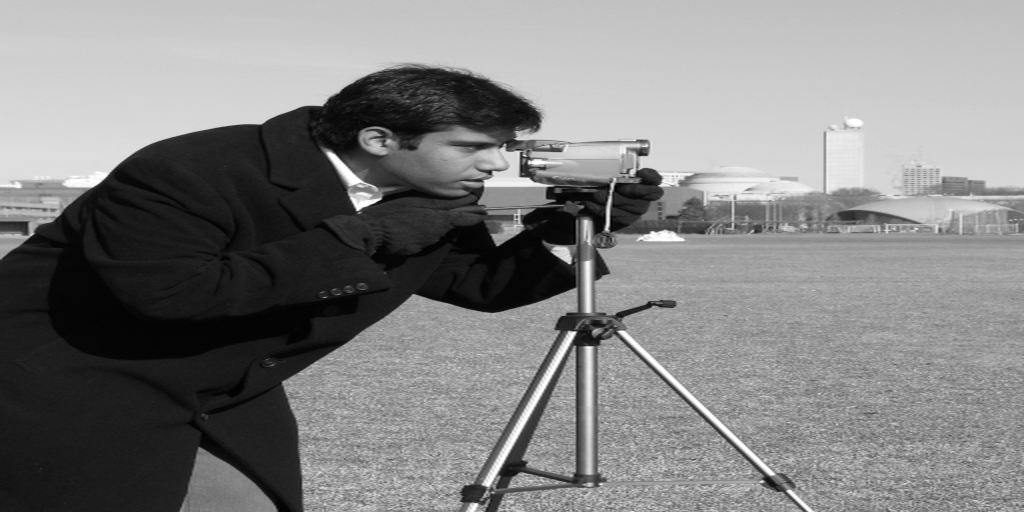

In [9]:
# Resize using the non-uniform factors
non_uniform_size = (width * cx, height * cy)
non_uniform_scaled_image = image.resize(non_uniform_size, Image.Resampling.LANCZOS)

non_uniform_scaled_image

In [10]:
# Save the non-uniform scaled image and print the sizes
non_uniform_scaled_image.save("task1_1b_nonuniform_scaled.jpg")
print(f"Original size: {image.size}")
print(f"Non-uniform scaled size: {non_uniform_scaled_image.size}")

Original size: (512, 512)
Non-uniform scaled size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [ ]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_image = image.rotate(120, expand=True)

# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_image.save("task1_2_rotated.jpg")
print(f"Original size: {image.size}")
print(f"Rotated size: {rotated_image.size}")

rotated_image

Original size: (512, 512)
Rotated size: (700, 700)


### 3. Shear

In [12]:
# -- c. Get the image dimensions ────────────────────
width, height = image.size
print(f"Image size: {width} x {height}")

Image size: 512 x 512


In [13]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5  # X-axis shear

# The canvas has to grow horizontally so the slanted image still fits
new_width = int(width + shear_factor * height)
new_height = height

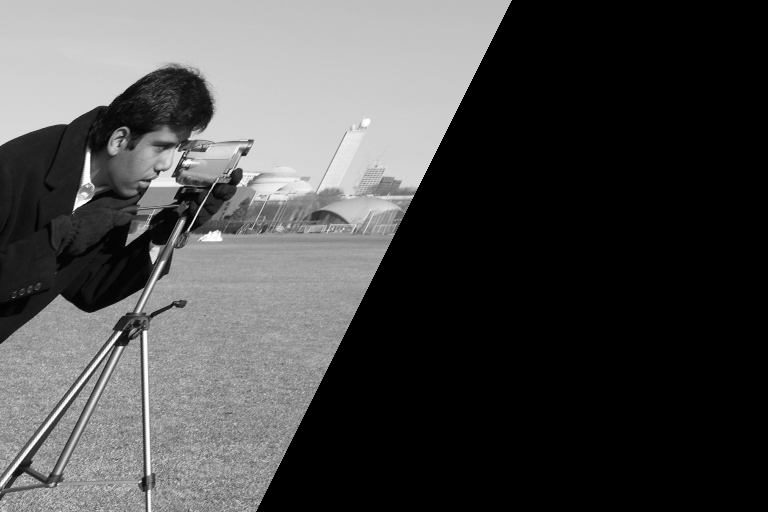

In [14]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
shear_matrix = (1, shear_factor, 0,
                 0, 1, 0)

sheared_image = image.transform((new_width, new_height), Image.AFFINE, shear_matrix, resample=Image.BICUBIC)

sheared_image

In [15]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_image.save("task1_3_sheared.jpg")
print(f"Original size: {image.size}")
print(f"Sheared size: {sheared_image.size}")

Original size: (512, 512)
Sheared size: (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

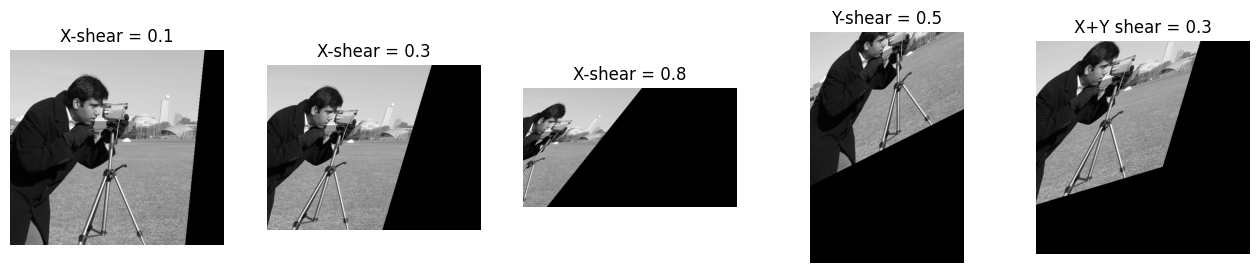

In [16]:
# Try a few different shear factors on the X-axis
shear_x_01 = image.transform((int(width + 0.1 * height), height), Image.AFFINE, (1, 0.1, 0, 0, 1, 0), resample=Image.BICUBIC)
shear_x_03 = image.transform((int(width + 0.3 * height), height), Image.AFFINE, (1, 0.3, 0, 0, 1, 0), resample=Image.BICUBIC)
shear_x_08 = image.transform((int(width + 0.8 * height), height), Image.AFFINE, (1, 0.8, 0, 0, 1, 0), resample=Image.BICUBIC)

# Switch to a Y-axis shear matrix instead — now the canvas height grows
shy = 0.5
shear_y_05 = image.transform((width, int(height + shy * width)), Image.AFFINE, (1, 0, 0, shy, 1, 0), resample=Image.BICUBIC)

# Combine X and Y shear in one matrix
shx_combo, shy_combo = 0.3, 0.3
combined_shear = image.transform(
    (int(width + shx_combo * height), int(height + shy_combo * width)),
    Image.AFFINE, (1, shx_combo, 0, shy_combo, 1, 0), resample=Image.BICUBIC
)

plt.figure(figsize=(16, 3))
plt.subplot(1, 5, 1), plt.imshow(shear_x_01, cmap='gray'), plt.title('X-shear = 0.1'), plt.axis('off')
plt.subplot(1, 5, 2), plt.imshow(shear_x_03, cmap='gray'), plt.title('X-shear = 0.3'), plt.axis('off')
plt.subplot(1, 5, 3), plt.imshow(shear_x_08, cmap='gray'), plt.title('X-shear = 0.8'), plt.axis('off')
plt.subplot(1, 5, 4), plt.imshow(shear_y_05, cmap='gray'), plt.title('Y-shear = 0.5'), plt.axis('off')
plt.subplot(1, 5, 5), plt.imshow(combined_shear, cmap='gray'), plt.title('X+Y shear = 0.3'), plt.axis('off')
plt.show()

# Observation: a bigger shear factor slants the image more, and the canvas
# has to grow accordingly (width for X-shear, height for Y-shear) so nothing
# gets cropped. Combining both matrices slants the image along both axes at once.

# Intensity Transformations
Negative · Log · Power Law (Gamma)

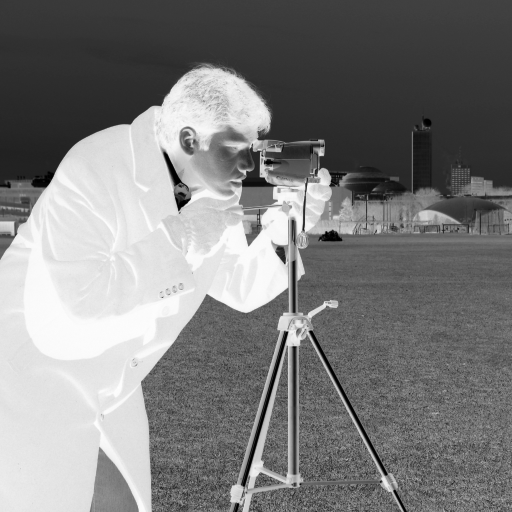

In [17]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
img_arr = np.array(image)
negative_arr = 255 - img_arr
negative_image_np = Image.fromarray(negative_arr.astype(np.uint8))

negative_image_np

Both methods match: True


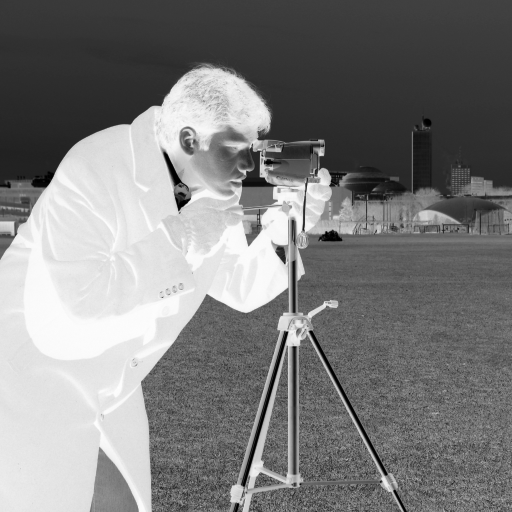

In [18]:
# Method 2: PIL's ImageOps
negative_image_ops = ImageOps.invert(image)

# Both methods should give the exact same result
print("Both methods match:", np.array_equal(np.array(negative_image_np), np.array(negative_image_ops)))
negative_image_ops

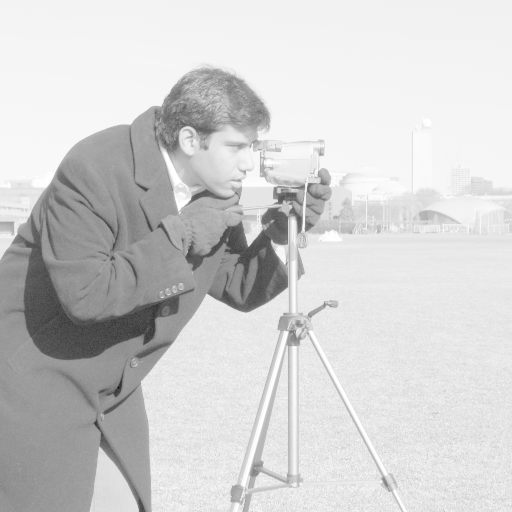

In [19]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

# Cast to float first: the image array is uint8 (0-255), so 1 + 255 would
# overflow and wrap around to 0, which is what caused log(0) = -inf before.
img_arr_float = np.array(image, dtype=np.float64)
c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_transformed_arr = c * np.log(1 + img_arr_float)
log_transformed_image = Image.fromarray(np.uint8(log_transformed_arr))

log_transformed_image

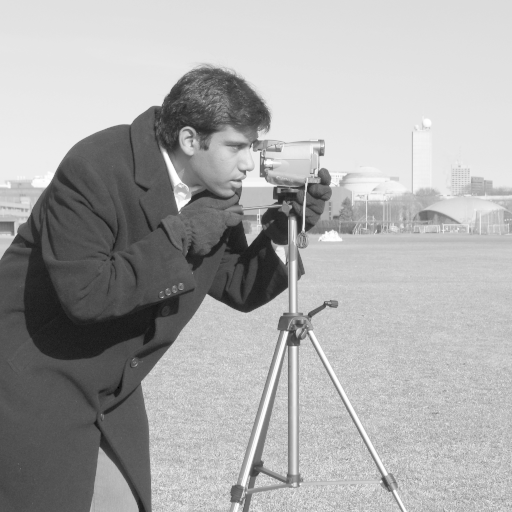

In [20]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5  # gamma < 1 brightens the image, gamma > 1 darkens it

img_arr_norm = np.array(image, dtype=np.float64) / 255.0
gamma_corrected_arr = np.power(img_arr_norm, gamma) * 255
gamma_corrected_image = Image.fromarray(np.uint8(gamma_corrected_arr))

gamma_corrected_image

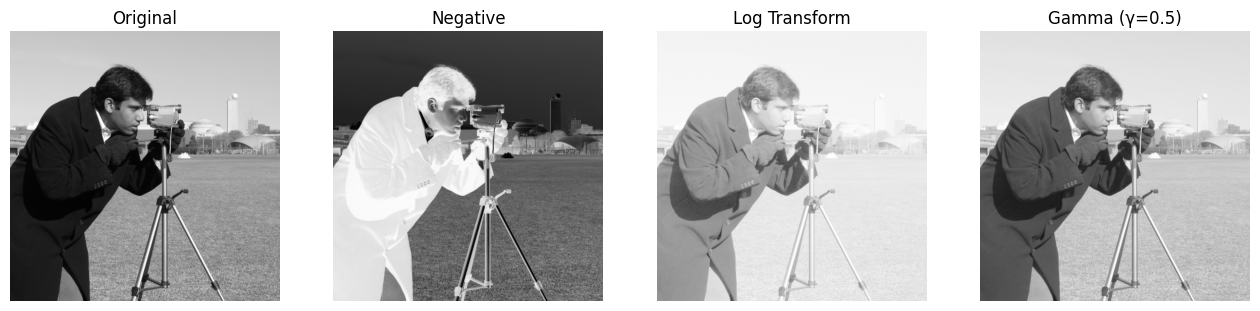

In [ ]:
# Compare all intensity transformations side by side
plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1), plt.imshow(image, cmap='gray'), plt.title('Original'), plt.axis('off')
plt.subplot(1, 4, 2), plt.imshow(negative_image_np, cmap='gray'), plt.title('Negative'), plt.axis('off')
plt.subplot(1, 4, 3), plt.imshow(log_transformed_image, cmap='gray'), plt.title('Log Transform'), plt.axis('off')
plt.subplot(1, 4, 4), plt.imshow(gamma_corrected_image, cmap='gray'), plt.title(f'Gamma (γ={gamma})'), plt.axis('off')
plt.show()

# Save the intensity-transformed images
negative_image_np.save("task2_1_negative.jpg")
log_transformed_image.save("task2_2_log.jpg")
gamma_corrected_image.save("task2_3_gamma.jpg")